/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.3146 - val_loss: 0.0998
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0367 - val_loss: 0.0050
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0107 - val_loss: 0.0015
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0089 - val_loss: 0.0014
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0060 - val_loss: 6.3945e-04
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0063 - val_loss: 6.0303e-04
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0055 - val_loss: 8.9266e-04
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0048 - val_loss: 4.6130e-04
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0050 - val_loss: 0.0018
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0052 - val_loss: 5.0855e-04
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0047 - val_loss: 0.0016
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - los

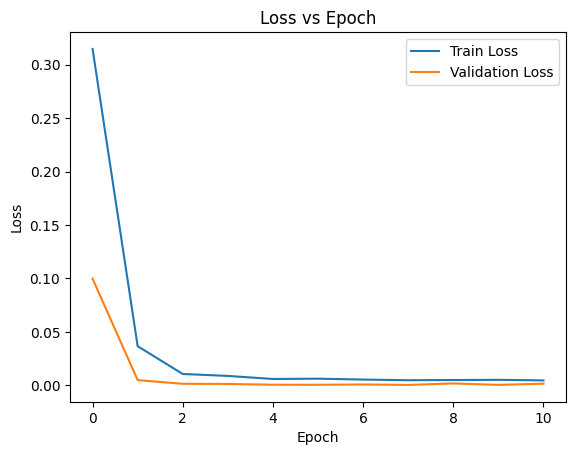

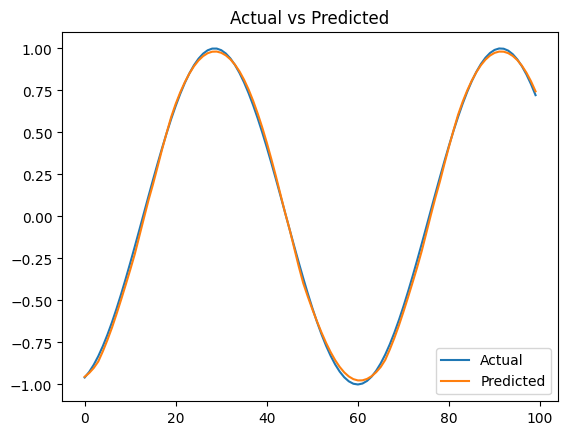

In [1]:
# Name= Shubham Goel

# Roll_no = 2501940014

# =====================================
# EXPERIMENT 3: LSTM (TIME SERIES)
# =====================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# =====================================
# 1. CREATE DATASET (SINE WAVE)
# =====================================
data = np.sin(np.arange(0, 100, 0.1))

# =====================================
# 2. CREATE SEQUENCES
# =====================================
def create_sequences(data, window=20):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window_size = 20
X, y = create_sequences(data, window_size)

# reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

# =====================================
# 3. TRAIN-TEST SPLIT
# =====================================
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# =====================================
# 4. BUILD MODEL (IMPROVED)
# =====================================
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size,1)),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# =====================================
# 5. COMPILE
# =====================================
model.compile(optimizer='adam', loss='mse')

model.summary()

# =====================================
# 6. TRAIN (WITH EARLY STOPPING)
# =====================================
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

# =====================================
# 7. EVALUATE
# =====================================
loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)

# =====================================
# 8. PREDICTIONS
# =====================================
y_pred = model.predict(X_test)

# =====================================
# 9. PLOT GRAPHS
# =====================================

# Loss Graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Actual vs Predicted
plt.plot(y_test[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.title("Actual vs Predicted")
plt.legend()
plt.show()